# RTB2004 segmented-acquisition timestamp check

`rtb2004.py`'s `run()` configures `ACQuire:MEMory MANual` + `ACQuire:POINts 10000` +
`TIMebase:SCALe` together for segmented (history) acquisition. It's not obvious from
reading the driver alone whether `set_timebase()` is actually doing what we think it is
once combined with segmented mode -- this notebook is a direct hardware check.

**Physical setup (done externally, not by this notebook):**
- An 80 MHz sine wave, amplitude-modulated by a 10 kHz square wave, into **Channel 1**.
- The 10 kHz square wave alone into the **EXT TRIG** input.

**What we're checking:** with the scope externally triggered once per square-wave edge,
consecutive segments should be timestamped 1/10kHz = 100 us apart. `run()` triggers off
`TRIGger:A:SOURce EXT` (see `set_trigger_edge()`), and `get_timetable()` reads back
`CHANnel1:HISTory:TSRelative:ALL?` -- the per-segment timestamps relative to the trigger.
If those come back evenly spaced at 100 us with small jitter, the segmented-trigger and
timestamping path is self-consistent. (Note: `TSRelative` timestamps come from the scope's
trigger/history clock, not the horizontal sample clock -- see the last section for a
second check that more directly stresses `set_timebase()`'s reported sample rate.)

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))  # rtb2004.py lives in experiment/, one level up
from rtb2004 import RTB2004

RESOURCE = "USB0::0x0AAD::0x01D6::108904::INSTR"
TRIGGER_FREQ_HZ = 10e3
EXPECTED_PERIOD_S = 1 / TRIGGER_FREQ_HZ
N_SEGMENTS = 200

os.makedirs("data", exist_ok=True)

In [2]:
scope = RTB2004(RESOURCE, timeout=100000, debug=True)

RTB2004: connected


In [3]:
# Same call path as production use: configures the timebase, arms segmented
# acquisition, waits for all N_SEGMENTS external triggers, then reads out and
# saves every segment's waveform to data/timebase_check.npy.
scope.run(segments=N_SEGMENTS, ch=1, path="data", name="timebase_check")

sample rate 2500000000.0


acquired segments 200


0 segments done


ETA: 46.13132000085898 s


100 segments done


time acquire 40.30671309999889 s
time save 0.008757799994782545 s


In [4]:
raw = scope.get_timetable(ch=1)
timestamps_s = np.array([float(x) for x in raw.split(",")])
print(f"{len(timestamps_s)} timestamps, first 5: {timestamps_s[:5]}")
print(f"last 5: {timestamps_s[-5:]}")

assert len(timestamps_s) == N_SEGMENTS, (
    f"expected {N_SEGMENTS} timestamps, got {len(timestamps_s)} -- "
    "did the full segment count actually get acquired?"
)
assert np.all(np.diff(timestamps_s) > 0), "timestamps are not monotonically increasing"

200 timestamps, first 5: [-0.01989999 -0.01979999 -0.01969999 -0.01959999 -0.01949999]
last 5: [-0.0004 -0.0003 -0.0002 -0.0001 -0.    ]


In [5]:
diffs_s = np.diff(timestamps_s)

mean_diff = diffs_s.mean()
std_diff = diffs_s.std()
rel_error = (mean_diff - EXPECTED_PERIOD_S) / EXPECTED_PERIOD_S

print(f"expected inter-segment spacing: {EXPECTED_PERIOD_S*1e6:.3f} us")
print(f"measured mean spacing:          {mean_diff*1e6:.3f} us  (rel. error {rel_error*100:+.3f}%)")
print(f"measured std of spacing:        {std_diff*1e9:.1f} ns")
print(f"measured min/max spacing:       {diffs_s.min()*1e6:.3f} / {diffs_s.max()*1e6:.3f} us")

expected inter-segment spacing: 100.000 us
measured mean spacing:          100.000 us  (rel. error -0.000%)
measured std of spacing:        0.6 ns
measured min/max spacing:       99.994 / 100.000 us


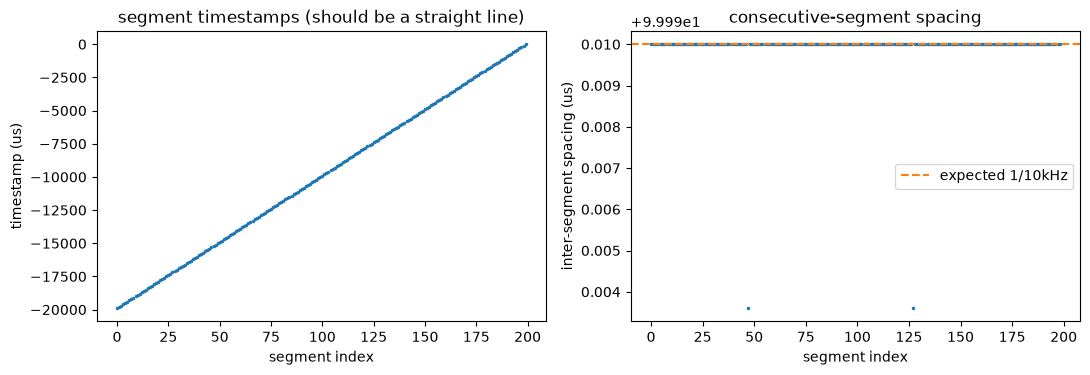

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(timestamps_s * 1e6, ".", ms=3)
axes[0].set_xlabel("segment index")
axes[0].set_ylabel("timestamp (us)")
axes[0].set_title("segment timestamps (should be a straight line)")

axes[1].plot(diffs_s * 1e6, ".", ms=3)
axes[1].axhline(EXPECTED_PERIOD_S * 1e6, color="C1", ls="--", label="expected 1/10kHz")
axes[1].set_xlabel("segment index")
axes[1].set_ylabel("inter-segment spacing (us)")
axes[1].set_title("consecutive-segment spacing")
axes[1].legend()

fig.tight_layout()

If the plot on the right is flat at the dashed line with only small (sub-percent) jitter,
and the left plot is a clean straight line, segmented triggering + timestamping is
consistent with the 10 kHz trigger. Large jitter, a nonzero slope/offset relative to the
dashed line, or `N_SEGMENTS` not matching what came back would all point to a real problem
(missed/extra triggers, or a timestamp clock that isn't what we think it is).

## Bonus check: does the *sample* clock match `set_timebase()`'s reported rate?

The check above validates the scope's trigger/history timestamp clock, which is separate
hardware from the horizontal sample clock that `set_timebase()` actually configures. As a
more direct test of `set_timebase()`, we can use the known 80 MHz carrier already sitting
in every captured segment: count its zero crossings over one segment and back out an
implied sample rate. If that doesn't match `ACQuire:SRATe?`'s reported value (used to
compute `sample_rate` inside `run()`), `set_timebase()` -- or the manual-points/segmented
combination around it -- has a real bug.

In [7]:
CARRIER_FREQ_HZ = 80e6

reported_sample_rate_hz = float(scope.query("ACQuire:SRATe?"))
print(f"scope-reported sample rate: {reported_sample_rate_hz/1e9:.4f} GSa/s")

segments = np.load("data/timebase_check.npy")
print(f"loaded segments array: {segments.shape}")

# Use a handful of segments (not all -- amplitude modulation may null out the
# carrier near some square-wave edges) and average the implied frequency.
implied_freqs_hz = []
for seg in segments[: min(20, len(segments))]:
    seg = seg - seg.mean()
    zero_crossings = np.where(np.diff(np.signbit(seg)))[0]
    if len(zero_crossings) < 4:
        continue  # modulation likely nulled the carrier in this segment
    n_periods = (len(zero_crossings) - 1) / 2
    duration_s = (zero_crossings[-1] - zero_crossings[0]) / reported_sample_rate_hz
    implied_freqs_hz.append(n_periods / duration_s)

implied_freqs_hz = np.array(implied_freqs_hz)
print(f"segments used: {len(implied_freqs_hz)}")
print(f"implied carrier freq (using reported sample rate): "
      f"{implied_freqs_hz.mean()/1e6:.4f} +/- {implied_freqs_hz.std()/1e6:.4f} MHz "
      f"(expected {CARRIER_FREQ_HZ/1e6:.1f} MHz)")

scope-reported sample rate: 2.5000 GSa/s
loaded segments array: (200, 10000)
segments used: 20
implied carrier freq (using reported sample rate): 80.4004 +/- 0.2294 MHz (expected 80.0 MHz)


If the implied carrier frequency above is off from 80 MHz by more than counting-resolution
jitter would explain, `ACQuire:SRATe?` (and therefore `set_timebase()`'s return value) does
not reflect the scope's true sample interval under `ACQuire:MEMory MANual` + segmented mode
-- that would be a real, separate bug from anything the timestamp check above can see.

## One segment, plotted with the corrected `make_t`, and the original peak-frequency finder

`rtb2004.py` now writes a `{name}_metadata.txt` alongside every saved sweep (sample
rate, true trigger-relative `t0_s`, and point count), and `make_t_from_metadata()` reads
it back and builds the time axis directly -- no live connection to the scope needed, and
no `/4` correction or centered-on-0 assumption (see its docstring and notes.md). Here we
plot one segment against that reconstructed time axis, then reproduce the peak-frequency
result using the same `compute_fft`/`get_peak_freq` functions used previously, to confirm
they report the correct ~80 MHz carrier.

In [8]:
from rtb2004 import make_t_from_metadata


def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)

    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)

    return f, np.abs(Y / len(y))


def get_peak_freq(t, y):
    f, Y = compute_fft(t, y)
    Y = np.abs(Y)
    return np.abs(f[np.argmax(Y)]) / 1e6


# Reconstructed entirely from data/timebase_check_metadata.txt -- no live
# scope connection needed for this part.
t_s = make_t_from_metadata("data/timebase_check_metadata.txt")
print(f"t: {len(t_s)} points, span = [{t_s[0]*1e9:.1f}, {t_s[-1]*1e9:.1f}] ns")

# Pick a segment with a strong carrier (amplitude modulation can null it out
# near some square-wave edges) rather than assuming segment 0 is representative.
seg_index = int(np.argmax(np.abs(segments - segments.mean(axis=1, keepdims=True)).max(axis=1)))
segment_v = segments[seg_index]
print(f"using segment {seg_index}")

t: 10000 points, span = [1000.0, 4999.6] ns
using segment 3


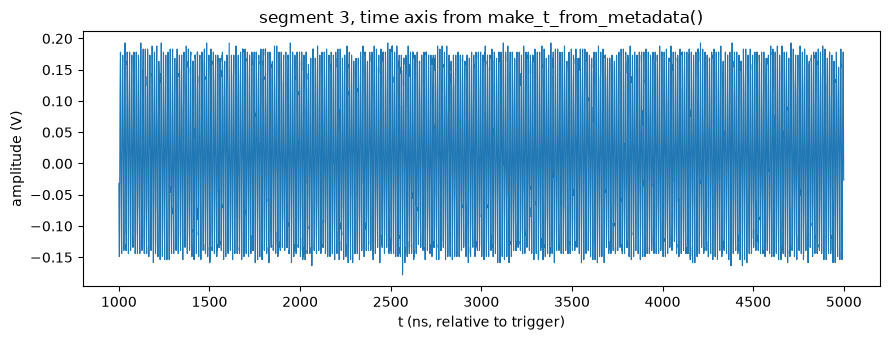

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_s * 1e9, segment_v, lw=0.8)
ax.set_xlabel("t (ns, relative to trigger)")
ax.set_ylabel("amplitude (V)")
ax.set_title(f"segment {seg_index}, time axis from make_t_from_metadata()")
fig.tight_layout()

get_peak_freq (with corrected make_t): 80.0000 MHz (expected 80.0 MHz)


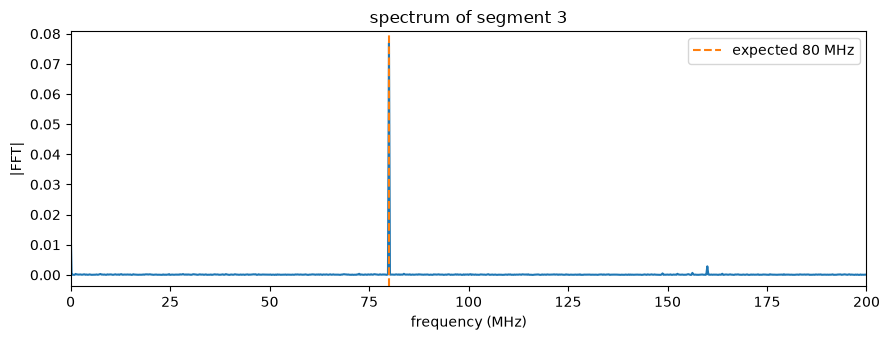

In [10]:
peak_freq_mhz = get_peak_freq(t_s, segment_v)
print(f"get_peak_freq (with corrected make_t): {peak_freq_mhz:.4f} MHz (expected {CARRIER_FREQ_HZ/1e6:.1f} MHz)")

f_axis, Y = compute_fft(t_s, segment_v)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(f_axis / 1e6, Y)
ax.axvline(CARRIER_FREQ_HZ / 1e6, color="C1", ls="--", label="expected 80 MHz")
ax.set_xlim(0, 200)
ax.set_xlabel("frequency (MHz)")
ax.set_ylabel("|FFT|")
ax.set_title(f"spectrum of segment {seg_index}")
ax.legend()
fig.tight_layout()

In [11]:
scope.close()